# All Experiments Comparison - Bar Charts

This notebook compares all segmentation experiments using bar charts with average values:

- **E1**: Baseline comparison
  - E1-no: Baseline without augmentation
  - E2-base: Baseline with augmentation
- **E2**: Architecture comparison
  - E2-base: 2D with augmentation (baseline)
  - E2-2.5D: 2.5D architecture (multi-slice input)
  - E2-3D: Full 3D architecture
- **E3**: Loss function comparison
  - E2-2.5D: Baseline 2.5D architecture
  - E3-CE-Dice: Combined Cross-Entropy and Dice loss
  - E3-Dice: Dice loss only
  - E3-Focal: Focal loss


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'

base_dir = Path("/home/s222440401/project/segmentation_experiment")

# ---- Publication figure export setup ----
# 174 mm = double-column journal width (~6.85 in)
MM_PER_INCH = 25.4
WIDTH_DOUBLE_IN = 174.0 / MM_PER_INCH  # ~6.85 in

FIG_DIR = Path("/home/s222440401/project/segmentation_experiment/report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name, fig=None, dpi=600):
    """Save current (or given) figure as PNG and PDF at >= 600 DPI."""
    if fig is None:
        fig = plt.gcf()
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight", facecolor="white")

# Publication-appropriate sizing for a 174 mm wide figure
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 7,
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'grid.linewidth': 0.4,
    'patch.linewidth': 0.6,
})


## 1. Load Data


In [2]:
# Define E2 experiment directories
e2_experiments = {
    'E2-base': base_dir / 'E1-augmentation',
    'E2-2.5D': base_dir / 'E2-2.5D',
    'E2-3D': base_dir / 'E2-3D'
}

# Load training efficiency data
training_data = {}
for exp_name, exp_dir in e2_experiments.items():
    eff_file = exp_dir / 'training_reports' / 'training_efficiency.csv'
    if eff_file.exists():
        df = pd.read_csv(eff_file)
        df['experiment'] = exp_name
        training_data[exp_name] = df
        print(f"Loaded {exp_name}: {len(df)} runs")

# Combine all training data
all_training = pd.concat(training_data.values(), ignore_index=True)
print(f"\nTotal training runs: {len(all_training)}")


Loaded E2-base: 5 runs
Loaded E2-2.5D: 5 runs
Loaded E2-3D: 5 runs

Total training runs: 15


In [3]:
# Load convergence data
convergence_data = {}
for exp_name, exp_dir in e2_experiments.items():
    conv_file = exp_dir / 'training_reports' / 'convergence.csv'
    if conv_file.exists():
        df = pd.read_csv(conv_file)
        df['experiment'] = exp_name
        convergence_data[exp_name] = df

if convergence_data:
    all_convergence = pd.concat(convergence_data.values(), ignore_index=True)
    print(f"Convergence data available for: {list(convergence_data.keys())}")
else:
    all_convergence = pd.DataFrame()
    print("No convergence data available")


Convergence data available for: ['E2-base', 'E2-2.5D', 'E2-3D']


## 2. Calculate Average Values


In [4]:
# Calculate average values for training metrics
e2_avg_training = all_training.groupby('experiment').agg({
    'Total Training Time (hours)': 'mean',
    'Average Epoch Time(s)': 'mean',
    'Average RAM (GB)': 'mean',
    'Average GPU Memory (GB)': 'mean',
    'CO2 Emissions (kg)': 'mean'
}).round(3)

print("Average Training Metrics:")
print(e2_avg_training)


Average Training Metrics:
            Total Training Time (hours)  Average Epoch Time(s)  \
experiment                                                       
E2-2.5D                          18.629               3353.240   
E2-3D                             5.257                 94.618   
E2-base                          16.354               2943.707   

            Average RAM (GB)  Average GPU Memory (GB)  CO2 Emissions (kg)  
experiment                                                                 
E2-2.5D                1.255                    0.373               1.606  
E2-3D                  1.316                    0.294               0.466  
E2-base                1.245                    0.373               1.667  


In [5]:
# Calculate average values for convergence metrics
if not all_convergence.empty:
    e2_avg_convergence = all_convergence.groupby('experiment').agg({
        'Convergence Epoch': 'mean',
        'Total Training Time (hours)': 'mean'
    }).round(2)
    
    print("Average Convergence Metrics:")
    print(e2_avg_convergence)
else:
    e2_avg_convergence = pd.DataFrame()


Average Convergence Metrics:
            Convergence Epoch  Total Training Time (hours)
experiment                                                
E2-2.5D                  14.0                        13.11
E2-3D                    67.0                         1.78
E2-base                  23.0                        18.84


In [6]:
# Calculate resource usage until convergence
if not all_convergence.empty:
    e2_resources = []
    
    for exp in e2_avg_training.index:
        conv_data = all_convergence[all_convergence['experiment'] == exp].reset_index(drop=True)
        train_data = all_training[all_training['experiment'] == exp].reset_index(drop=True)
        
        if not conv_data.empty and not train_data.empty:
            min_len = min(len(conv_data), len(train_data))
            for i in range(min_len):
                # Calculate total epochs from training data (full training)
                total_epochs_full = train_data.loc[i, 'Total Training Time (second)'] / train_data.loc[i, 'Average Epoch Time(s)']
                # Calculate average CO2 per epoch from full training
                avg_co2_per_epoch = train_data.loc[i, 'CO2 Emissions (kg)'] / total_epochs_full
                # Calculate CO2 until convergence: average per epoch × convergence epoch
                total_co2_until_conv = avg_co2_per_epoch * conv_data.loc[i, 'Convergence Epoch']
                
                e2_resources.append({
                    'experiment': exp,
                    'Convergence Epoch': conv_data.loc[i, 'Convergence Epoch'],
                    'Avg RAM per Epoch (GB)': train_data.loc[i, 'Average RAM (GB)'],
                    'Avg GPU per Epoch (GB)': train_data.loc[i, 'Average GPU Memory (GB)'],
                    'Avg CO2 per Epoch (kg)': avg_co2_per_epoch,
                    'Total RAM until Convergence (GB·epochs)': train_data.loc[i, 'Average RAM (GB)'] * conv_data.loc[i, 'Convergence Epoch'],
                    'Total GPU until Convergence (GB·epochs)': train_data.loc[i, 'Average GPU Memory (GB)'] * conv_data.loc[i, 'Convergence Epoch'],
                    'Total CO2 until Convergence (kg)': total_co2_until_conv
                })
    
    if e2_resources:
        e2_resources_df = pd.DataFrame(e2_resources)
        e2_avg_resources = e2_resources_df.groupby('experiment').agg({
            'Total RAM until Convergence (GB·epochs)': 'mean',
            'Total GPU until Convergence (GB·epochs)': 'mean',
            'Total CO2 until Convergence (kg)': 'mean'
        }).round(3)
        
        print("Average Resource Usage Until Convergence:")
        print(e2_avg_resources)
    else:
        e2_avg_resources = pd.DataFrame()
else:
    e2_avg_resources = pd.DataFrame()


Average Resource Usage Until Convergence:
            Total RAM until Convergence (GB·epochs)  \
experiment                                            
E2-2.5D                                      17.586   
E2-3D                                        88.160   
E2-base                                      28.638   

            Total GPU until Convergence (GB·epochs)  \
experiment                                            
E2-2.5D                                       5.221   
E2-3D                                        19.666   
E2-base                                       8.580   

            Total CO2 until Convergence (kg)  
experiment                                    
E2-2.5D                                1.124  
E2-3D                                  0.156  
E2-base                                1.905  


## 3. Bar Charts - Training Metrics


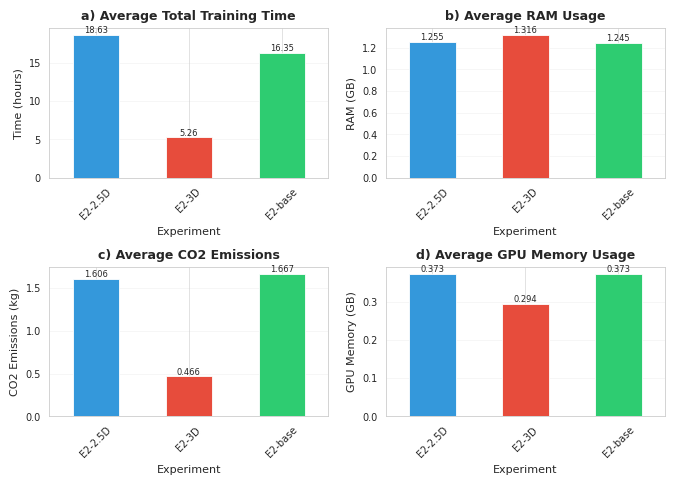

In [7]:
# Training time comparison
fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 10/14))

# Total Training Time
ax1 = axes[0, 0]
e2_avg_training['Total Training Time (hours)'].plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c', '#2ecc71'])
ax1.set_title('a) Average Total Training Time', fontsize=9, fontweight='bold')
ax1.set_xlabel('Experiment')
ax1.set_ylabel('Time (hours)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(e2_avg_training['Total Training Time (hours)']):
    ax1.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=6)

# Average RAM Usage
ax2 = axes[0, 1]
e2_avg_training['Average RAM (GB)'].plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c', '#2ecc71'])
ax2.set_title('b) Average RAM Usage', fontsize=9, fontweight='bold')
ax2.set_xlabel('Experiment')
ax2.set_ylabel('RAM (GB)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(e2_avg_training['Average RAM (GB)']):
    ax2.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=6)

# CO2 Emissions
ax3 = axes[1, 0]
e2_avg_training['CO2 Emissions (kg)'].plot(kind='bar', ax=ax3, color=['#3498db', '#e74c3c', '#2ecc71'])
ax3.set_title('c) Average CO2 Emissions', fontsize=9, fontweight='bold')
ax3.set_xlabel('Experiment')
ax3.set_ylabel('CO2 Emissions (kg)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(e2_avg_training['CO2 Emissions (kg)']):
    ax3.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=6)

# Average GPU Memory Usage
ax4 = axes[1, 1]
e2_avg_training['Average GPU Memory (GB)'].plot(kind='bar', ax=ax4, color=['#3498db', '#e74c3c', '#2ecc71'])
ax4.set_title('d) Average GPU Memory Usage', fontsize=9, fontweight='bold')
ax4.set_xlabel('Experiment')
ax4.set_ylabel('GPU Memory (GB)')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(e2_avg_training['Average GPU Memory (GB)']):
    ax4.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=6)

plt.tight_layout()
save_fig('e2_training_metrics')
plt.show()


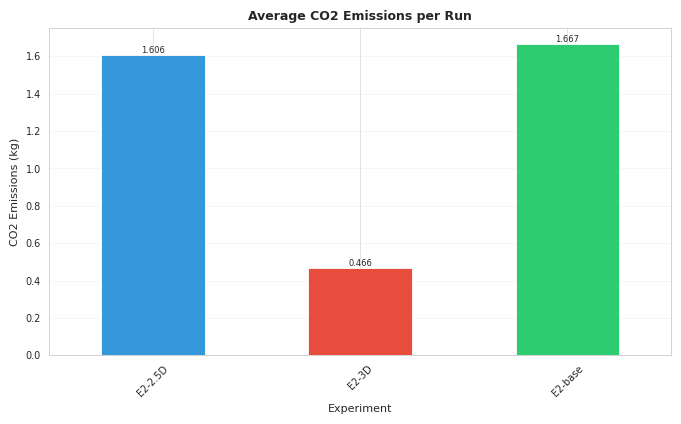

In [8]:
# CO2 Emissions
plt.figure(figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 5/8))
e2_avg_training['CO2 Emissions (kg)'].plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Average CO2 Emissions per Run', fontsize=9, fontweight='bold')
plt.xlabel('Experiment', fontsize=8)
plt.ylabel('CO2 Emissions (kg)', fontsize=8)
plt.xticks(rotation=45, fontsize=7)
plt.yticks(fontsize=7)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(e2_avg_training['CO2 Emissions (kg)']):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=6)
plt.tight_layout()
save_fig('e2_co2_per_run')
plt.show()


## 4. Bar Charts - Convergence Metrics


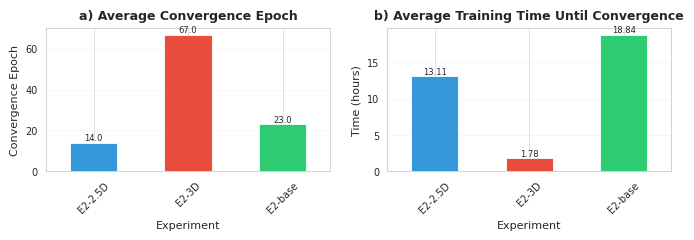

In [9]:
if not e2_avg_convergence.empty:
    fig, axes = plt.subplots(1, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 5/14))
    
    # Convergence Epoch
    ax1 = axes[0]
    e2_avg_convergence['Convergence Epoch'].plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax1.set_title('a) Average Convergence Epoch', fontsize=9, fontweight='bold')
    ax1.set_xlabel('Experiment')
    ax1.set_ylabel('Convergence Epoch')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    for i, v in enumerate(e2_avg_convergence['Convergence Epoch']):
        ax1.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=6)
    
    # Training Time until Convergence
    ax2 = axes[1]
    e2_avg_convergence['Total Training Time (hours)'].plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax2.set_title('b) Average Training Time Until Convergence', fontsize=9, fontweight='bold')
    ax2.set_xlabel('Experiment')
    ax2.set_ylabel('Time (hours)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    for i, v in enumerate(e2_avg_convergence['Total Training Time (hours)']):
        ax2.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=6)
    
    plt.tight_layout()
    save_fig('e2_convergence_metrics')
    plt.show()
else:
    print("No convergence data available")


## 5. Bar Charts - Resource Usage Until Convergence


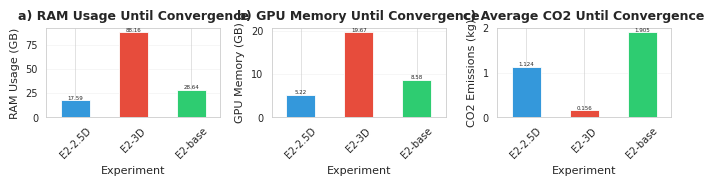

In [ ]:
if not e2_avg_resources.empty and not e2_avg_convergence.empty:
    fig, axes = plt.subplots(1, 3, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 5/18))
    
    # Total RAM until Convergence
    ax1 = axes[0]
    e2_avg_resources['Total RAM until Convergence (GB·epochs)'].plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax1.set_title('a) RAM Usage Until Convergence', fontsize=8, fontweight='bold')
    ax1.set_xlabel('Experiment')
    ax1.set_ylabel('RAM Usage (GB)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    for i, v in enumerate(e2_avg_resources['Total RAM until Convergence (GB·epochs)']):
        ax1.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=4)
    
    # Total GPU until Convergence
    ax2 = axes[1]
    e2_avg_resources['Total GPU until Convergence (GB·epochs)'].plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax2.set_title('b) GPU Memory Until Convergence', fontsize=8, fontweight='bold')
    ax2.set_xlabel('Experiment')
    ax2.set_ylabel('GPU Memory (GB)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    for i, v in enumerate(e2_avg_resources['Total GPU until Convergence (GB·epochs)']):
        ax2.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=4)
    
    # CO2 until Convergence (Average per Epoch × Convergence Epoch)
    ax3 = axes[2]
    e2_avg_resources['Total CO2 until Convergence (kg)'].plot(kind='bar', ax=ax3, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax3.set_title('c) Average CO2 Until Convergence', fontsize=8, fontweight='bold')
    ax3.set_xlabel('Experiment')
    ax3.set_ylabel('CO2 Emissions (kg)')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(axis='y', alpha=0.3)
    for i, v in enumerate(e2_avg_resources['Total CO2 until Convergence (kg)']):
        ax3.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=4)
    
    plt.tight_layout()
    save_fig('e2_resources_until_convergence')
    plt.show()
else:
    print("No resource usage data available")
